<a href="https://colab.research.google.com/github/asmaa-2003/LSTM-Anomaly--detection/blob/main/data1_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense

# تحسين الأداء
tf.keras.backend.clear_session()

In [ ]:
CHUNK_SIZE = 20000   # 🔥 أهم تعديل (يقلل عدد chunks)
BUFFER_SIZE = 2      # 🔥 أسرع تدريب
TIME_STEPS = 5       # مناسب وسريع
BATCH_SIZE = 32      # جيد
EPOCHS = 2           # 🔥 يقلل الوقت

In [ ]:
scaler = MinMaxScaler()

reader = pd.read_csv("MetroPT1.csv", chunksize=CHUNK_SIZE)

first_chunk = next(reader)

first_chunk['timestamp'] = pd.to_datetime(first_chunk['timestamp'])
first_chunk = first_chunk.sort_values('timestamp')

data_init = first_chunk.drop(columns=['timestamp']).values.astype(np.float32)

scaler.partial_fit(data_init)

print("✅ Scaler ready")

✅ Scaler ready


In [ ]:
n_features = data_init.shape[1]

inputs = Input(shape=(TIME_STEPS, n_features))

x = LSTM(32, activation='relu', return_sequences=True)(inputs)
x = LSTM(16, activation='relu')(x)

x = RepeatVector(TIME_STEPS)(x)

x = LSTM(16, activation='relu', return_sequences=True)(x)
x = LSTM(32, activation='relu', return_sequences=True)(x)

outputs = TimeDistributed(Dense(n_features))(x)

model = Model(inputs, outputs)

model.compile(optimizer='adam', loss='mse')

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5, 20)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 5, 32)          │         6,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 5, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 5, 16)          │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 5, 32)          │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 5, 20)          │           660 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,964 (74.08 KB)

 Trainable params: 18,964 (74.08 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def create_sequences(data, time_steps=5):
    X = []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
    return np.array(X)

In [ ]:
print("🚀 Training started...")

for epoch in range(EPOCHS):
    print(f"\n🔥 Epoch {epoch+1}")

    reader = pd.read_csv("MetroPT1.csv", chunksize=CHUNK_SIZE)

    buffer_X = []

    for i, chunk in enumerate(reader):
        print(f"Chunk {i}")

        # تنظيف
        chunk['timestamp'] = pd.to_datetime(chunk['timestamp'])


        # تحويل إلى numpy
        data = chunk.drop(columns=['timestamp']).values.astype(np.float32)

        # scaling
        data_scaled = scaler.transform(data)

        # sequences
        X = create_sequences(data_scaled, TIME_STEPS)

        if len(X) == 0:
            continue

        buffer_X.append(X)

        # 🔥 تدريب بعد جمع عدة chunks
        if len(buffer_X) == BUFFER_SIZE:
            X_train = np.concatenate(buffer_X, axis=0)

            model.fit(X_train, X_train, epochs=1, batch_size=BATCH_SIZE, verbose=0)

            buffer_X = []

            del X_train

        del X, data, data_scaled

    print("✅ Epoch finished")

🚀 Training started...

🔥 Epoch 1
Chunk 0
Chunk 1
Chunk 2
Chunk 3
Chunk 4
Chunk 5
Chunk 6
Chunk 7
Chunk 8
Chunk 9
Chunk 10
Chunk 11
Chunk 12
Chunk 13
Chunk 14
Chunk 15
Chunk 16
Chunk 17
Chunk 18
Chunk 19
Chunk 20
Chunk 21
Chunk 22
Chunk 23
Chunk 24
Chunk 25
Chunk 26
Chunk 27
Chunk 28
Chunk 29
Chunk 30
Chunk 31
Chunk 32
Chunk 33
Chunk 34
Chunk 35
Chunk 36
Chunk 37
Chunk 38
Chunk 39
Chunk 40
Chunk 41
Chunk 42
Chunk 43
Chunk 44
Chunk 45
Chunk 46
Chunk 47
Chunk 48
Chunk 49
Chunk 50
Chunk 51
Chunk 52
Chunk 53
Chunk 54
Chunk 55
Chunk 56
Chunk 57
Chunk 58
Chunk 59
Chunk 60
Chunk 61
Chunk 62
Chunk 63
Chunk 64
Chunk 65
Chunk 66
Chunk 67
Chunk 68
Chunk 69
Chunk 70
Chunk 71
Chunk 72
Chunk 73
Chunk 74
Chunk 75
Chunk 76
Chunk 77
Chunk 78
Chunk 79
Chunk 80
Chunk 81
Chunk 82
Chunk 83
Chunk 84
Chunk 85
Chunk 86
Chunk 87
Chunk 88
Chunk 89
Chunk 90
Chunk 91
Chunk 92
Chunk 93
Chunk 94
Chunk 95
Chunk 96
Chunk 97
Chunk 98
Chunk 99
Chunk 100
Chunk 101
Chunk 102
Chunk 103
Chunk 104
Chunk 105
Chunk 106
Chunk 1

In [ ]:
test_df = pd.read_csv("MetroPT1.csv", nrows=20000)

test_df['timestamp'] = pd.to_datetime(test_df['timestamp'])
test_df = test_df.sort_values('timestamp')

test_data = test_df.drop(columns=['timestamp']).values.astype(np.float32)

test_scaled = scaler.transform(test_data)

X_test = create_sequences(test_scaled, TIME_STEPS)

print("Test shape:", X_test.shape)

Test shape: (19995, 5, 20)


In [ ]:
X_pred = model.predict(X_test)

mse = np.mean(np.power(X_test - X_pred, 2), axis=(1,2))

print("MSE shape:", mse.shape)

625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step
MSE shape: (19995,)


In [ ]:
threshold = np.mean(mse) + 3 * np.std(mse)

print("Threshold:", threshold)

anomalies = mse > threshold

print("Anomalies:", np.sum(anomalies))

Threshold: 0.19012925
Anomalies: 21


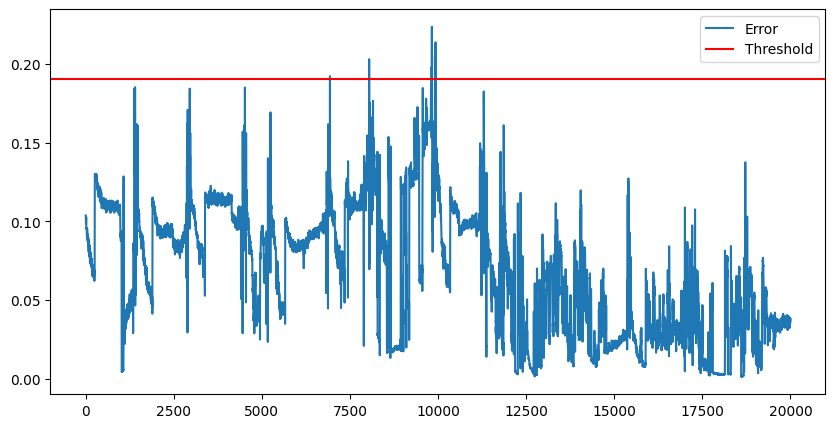

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(mse, label="Error")
plt.axhline(threshold, color='red', label="Threshold")
plt.legend()
plt.show()

Loading evaluation data (normal + failure periods)...
Eval set: 5,467,970 rows
  Normal  (0): 50,000
  Warning (1): 0
  Failure (2): 5,417,970
Sequences: (5467965, 5, 20)
True anomalies: 5,417,970 / 5,467,965

   EVALUATION RESULTS — LSTM Autoencoder
  Threshold  : 0.119744
  Precision  : 0.9992  (99.9%)
  Recall     : 0.5592  (55.9%)
  F1 Score   : 0.7171  (71.7%)
  ROC-AUC    : 0.5687
  Detected   : 3032306 / 5417970 real anomalies
              precision    recall  f1-score   support

      Normal       0.02      0.95      0.04     49995
     Anomaly       1.00      0.56      0.72   5417970

    accuracy                           0.56   5467965
   macro avg       0.51      0.75      0.38   5467965
weighted avg       0.99      0.56      0.71   5467965



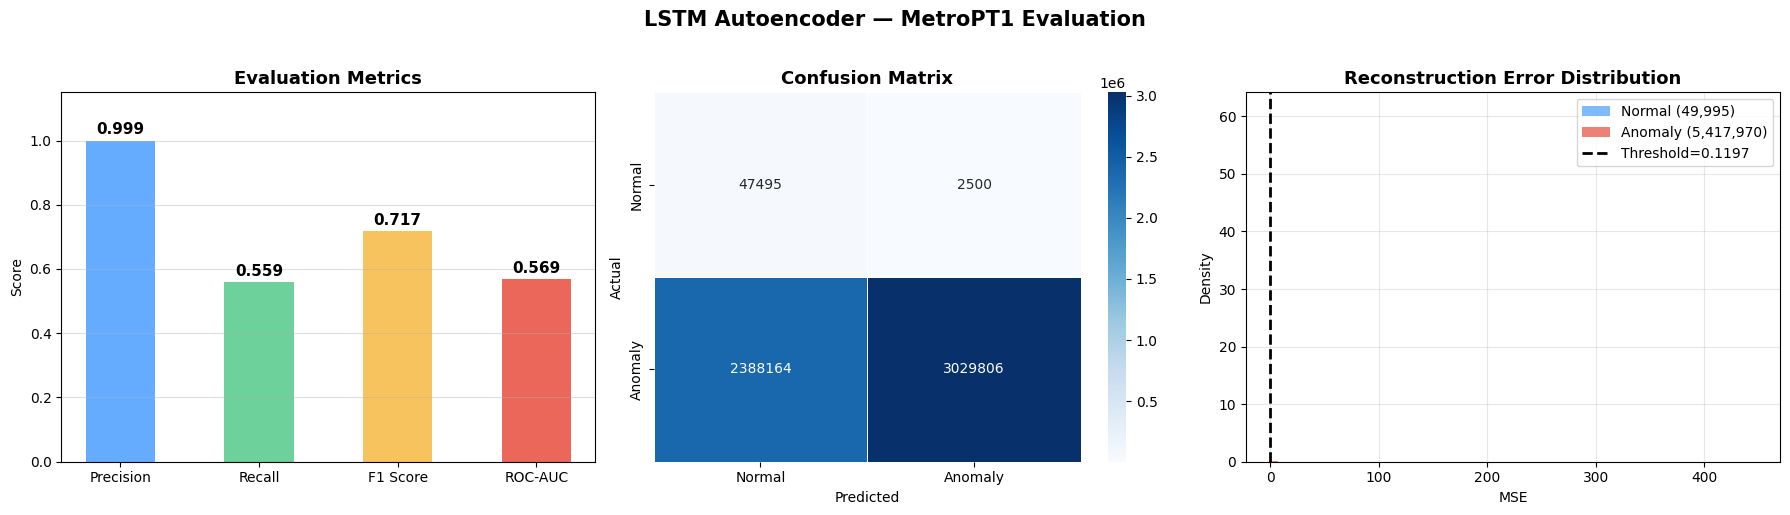

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# ── Load a window that contains real failures ──────────
WARNING_HOURS = 24
FAILURES = [
    ('2022-02-02', '2022-03-01', 'Air Leak — Clients'),
    ('2022-03-12', '2022-04-06', 'Air Leak — Dryer'),
    ('2022-05-09', '2022-06-03', 'Oil Leak — Compressor'),
]

print('Loading evaluation data (normal + failure periods)...')
chunks = []
normal_count = 0
MAX_NORMAL   = 50_000

for chunk in pd.read_csv('MetroPT1.csv',
                          parse_dates=['timestamp'],
                          chunksize=50_000):
    chunk = chunk.drop_duplicates('timestamp').sort_values('timestamp')
    ts    = chunk['timestamp']
    fail_mask = (
        ((ts >= '2022-02-02') & (ts <= '2022-03-01')) |
        ((ts >= '2022-03-12') & (ts <= '2022-04-06')) |
        ((ts >= '2022-05-09') & (ts <= '2022-06-03'))
    )
    if fail_mask.any():
        chunks.append(chunk[fail_mask])
    if normal_count < MAX_NORMAL:
        norm = chunk[~fail_mask]
        take = min(len(norm), MAX_NORMAL - normal_count)
        if take > 0:
            chunks.append(norm.iloc[:take])
            normal_count += take
    if ts.max() > pd.Timestamp('2022-06-10'):
        break

eval_df = pd.concat(chunks, ignore_index=True)
eval_df = eval_df.drop_duplicates('timestamp').sort_values('timestamp').reset_index(drop=True)
eval_df = eval_df.ffill().bfill()

# ── Add true labels ────────────────────────────────────
eval_df['label'] = 0
for s, e, ftype in FAILURES:
    t0 = pd.Timestamp(s)
    t1 = pd.Timestamp(e)
    tw = t0 - pd.Timedelta(hours=WARNING_HOURS)
    eval_df.loc[(eval_df['timestamp'] >= tw) & (eval_df['timestamp'] < t0), 'label'] = 1
    eval_df.loc[(eval_df['timestamp'] >= t0) & (eval_df['timestamp'] <= t1), 'label'] = 2

counts = eval_df['label'].value_counts().sort_index()
print(f'Eval set: {len(eval_df):,} rows')
print(f'  Normal  (0): {counts.get(0,0):,}')
print(f'  Warning (1): {counts.get(1,0):,}')
print(f'  Failure (2): {counts.get(2,0):,}')

# ── Scale & build sequences ────────────────────────────
feature_cols = eval_df.select_dtypes(include=[np.number]).columns.tolist()
for drop_col in ['label', 'is_anomaly']:
    if drop_col in feature_cols:
        feature_cols.remove(drop_col)

eval_scaled = scaler.transform(eval_df[feature_cols].values.astype(np.float32))
X_eval      = create_sequences(eval_scaled, TIME_STEPS)
y_true      = (eval_df['label'].values[TIME_STEPS:] >= 1).astype(int)

print(f'Sequences: {X_eval.shape}')
print(f'True anomalies: {y_true.sum():,} / {len(y_true):,}')

# ── Predict & compute metrics ──────────────────────────
X_pred_eval = model.predict(X_eval, batch_size=512, verbose=0)
mse_eval    = np.mean(np.power(X_eval - X_pred_eval, 2), axis=(1, 2))

threshold_eval = np.percentile(mse_eval[y_true == 0], 95)
y_pred_eval    = (mse_eval > threshold_eval).astype(int)

prec = precision_score(y_true, y_pred_eval, zero_division=0)
rec  = recall_score(y_true, y_pred_eval, zero_division=0)
f1   = f1_score(y_true, y_pred_eval, zero_division=0)
auc  = roc_auc_score(y_true, mse_eval) if y_true.sum() > 0 else 0.0

# ── Print results ──────────────────────────────────────
print('\n' + '='*50)
print('   EVALUATION RESULTS — LSTM Autoencoder')
print('='*50)
print(f'  Threshold  : {threshold_eval:.6f}')
print(f'  Precision  : {prec:.4f}  ({prec*100:.1f}%)')
print(f'  Recall     : {rec:.4f}  ({rec*100:.1f}%)')
print(f'  F1 Score   : {f1:.4f}  ({f1*100:.1f}%)')
print(f'  ROC-AUC    : {auc:.4f}')
print(f'  Detected   : {y_pred_eval.sum()} / {y_true.sum()} real anomalies')
print('='*50)
print(classification_report(y_true, y_pred_eval,
      target_names=['Normal', 'Anomaly']))

# ── Plots ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart
bars = axes[0].bar(
    ['Precision', 'Recall', 'F1 Score', 'ROC-AUC'],
    [prec, rec, f1, auc],
    color=['#4a9eff','#52c98a','#f5b942','#e74c3c'],
    alpha=0.85, width=0.5
)
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Evaluation Metrics', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].grid(axis='y', alpha=0.4)
for bar, val in zip(bars, [prec, rec, f1, auc]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.02,
                  f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_eval)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Anomaly'],
            yticklabels=['Normal','Anomaly'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# Error distribution
axes[2].hist(mse_eval[y_true==0], bins=60, alpha=0.7,
              color='#4a9eff', label=f'Normal ({(y_true==0).sum():,})', density=True)
axes[2].hist(mse_eval[y_true==1], bins=60, alpha=0.7,
              color='#e74c3c', label=f'Anomaly ({y_true.sum():,})', density=True)
axes[2].axvline(threshold_eval, color='black', lw=2, ls='--',
                 label=f'Threshold={threshold_eval:.4f}')
axes[2].set_title('Reconstruction Error Distribution', fontsize=13, fontweight='bold')
axes[2].set_xlabel('MSE')
axes[2].set_ylabel('Density')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('LSTM Autoencoder — MetroPT1 Evaluation',
              fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ae_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()